In [2]:
# cargando todas las librerías necesarias
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
# scales
from sklearn.preprocessing import MinMaxScaler
# labels categoricos
from sklearn.preprocessing import LabelEncoder
# seasonal
from statsmodels.tsa.seasonal import seasonal_decompose

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("Librerias importadas!")

Librerias importadas!


# Aplicación de técnicas de EDA en problemas reales

In [4]:
#1. carga y exploración del dataset

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
insurance = pd.read_csv(url)
#insurance.head()

# Revisión inicial
print(insurance.info())
print(insurance.describe())
print(insurance.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max

## Dist Edad

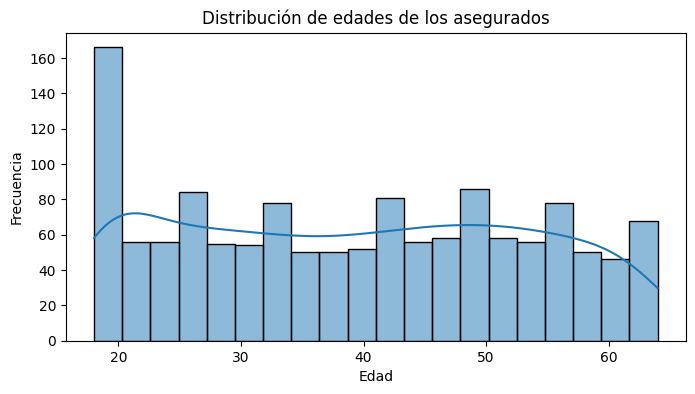

In [5]:
# distribución edades
plt.figure(figsize=(8, 4))
sns.histplot(insurance['age'], bins=20, kde=True)
plt.title("Distribución de edades de los asegurados")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


La gráfica muestra un histograma con suavizado (KDE) de la variable age, que representa las edades de los asegurados:

- Pico inicial pronunciado en los 18–20 años: hay una alta concentración de asegurados jóvenes, lo cual podría indicar una estrategia comercial orientada a captar a personas desde el inicio de su vida laboral o estudiantes que dependen aún de sus padres.
- Distribución bastante homogénea entre los 20 y los 60 años: la densidad de asegurados se mantiene relativamente estable, sin grandes vacíos entre rangos de edad, lo cual es ideal para una aseguradora que busca diversificación de riesgo.
- Ligero descenso a partir de los 60 años: esto podría reflejar una menor contratación por parte de adultos mayores, tal vez por costos más altos o menor cultura de aseguramiento en esa población.

## Evaluar la variable del IMC (bmi):

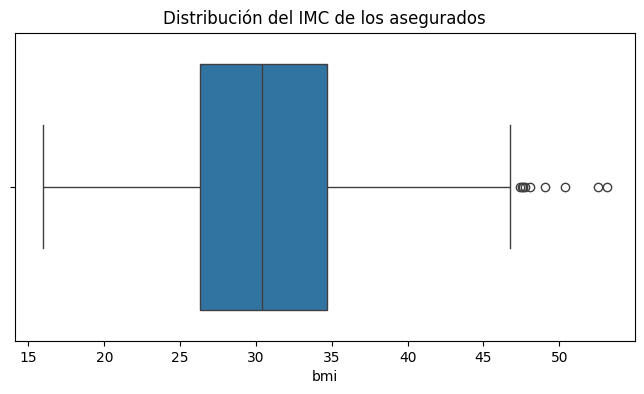

In [6]:
# distribución IMC

plt.figure(figsize=(8, 4))
sns.boxplot(data=insurance, x='bmi')
plt.title("Distribución del IMC de los asegurados")
plt.show()


Interpretación de la distribución del IMC (bmi)

- La mediana del IMC se encuentra cerca de 30, lo que indica que el valor central de la muestra cae dentro del rango de sobrepeso u obesidad grado I, según los criterios de la OMS. (World Health Organization [WHO], 2020)
- El rango intercuartílico (IQR) está entre aproximadamente 25 y 35, lo que sugiere que al menos el 50% de los asegurados presenta IMC en rangos no saludables.
- Se identifican algunos valores atípicos (outliers) por encima de 45, lo que implica la presencia de individuos con obesidad severa o mórbida.
- No se observan valores atípicos bajos, lo cual sugiere que los casos de bajo peso son inexistentes o mínimos en la muestra.

## Evaluar variable de Gastos médicos (charges).

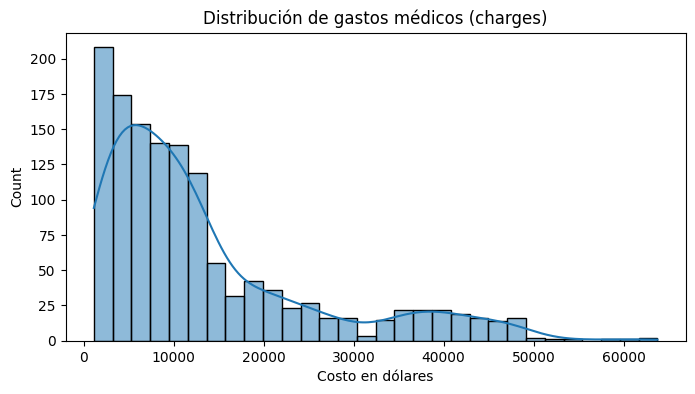

In [7]:
# Evaluamos Gastos médicos (charges):

plt.figure(figsize=(8, 4))
sns.histplot(insurance['charges'], bins=30, kde=True)
plt.title("Distribución de gastos médicos (charges)")
plt.xlabel("Costo en dólares")
plt.show()


La distribución está fuertemente sesgada a la derecha. La mayoría gasta menos de $15,000, pero hay varios asegurados con gastos mayores a $50,000. Esto podría estar asociado con factores como tabaquismo o edad avanzada.

# 3. Análisis de relaciones categóricas

## Gastos según fumador o no fumador:

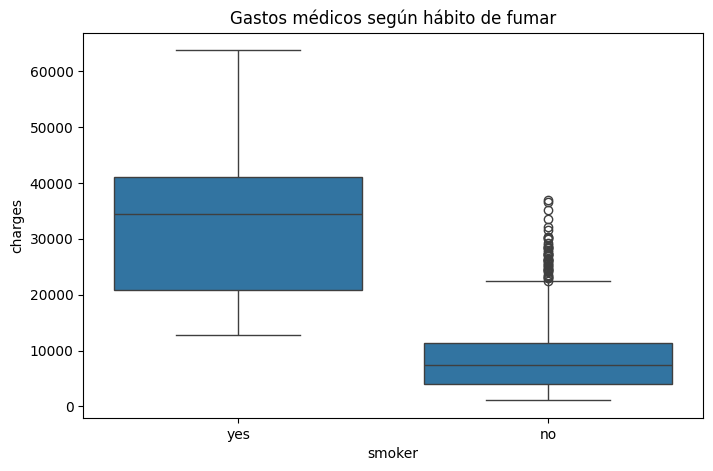

In [8]:
# 3. Análisis de relaciones categóricas
# Gastos según fumador o no fumador:

plt.figure(figsize=(8, 5))
sns.boxplot(data=insurance, x='smoker', y='charges')
plt.title("Gastos médicos según hábito de fumar")
plt.show()


Los fumadores tienden a tener gastos considerablemente más altos. Este hallazgo es clave para ajustar primas o políticas de prevención.



## 4. Detección de valores atípicos



In [9]:
# 4. Detección de valores atípicos
Q1 = insurance['charges'].quantile(0.25)
Q3 = insurance['charges'].quantile(0.75)
IQR = Q3 - Q1
outliers = insurance[(insurance['charges'] < Q1 - 1.5*IQR) | (insurance['charges'] > Q3 + 1.5*IQR)]

print(f"Se encontraron {len(outliers)} posibles outliers en los gastos médicos.")


Se encontraron 139 posibles outliers en los gastos médicos.


Se encontraron 139 posibles outliers en los gastos médicos. Algunos outliers son esperables, especialmente en fumadores o personas con enfermedades graves. No deben eliminarse sin una evaluación adicional.



# Modelado de series temporales en entornos empresariales

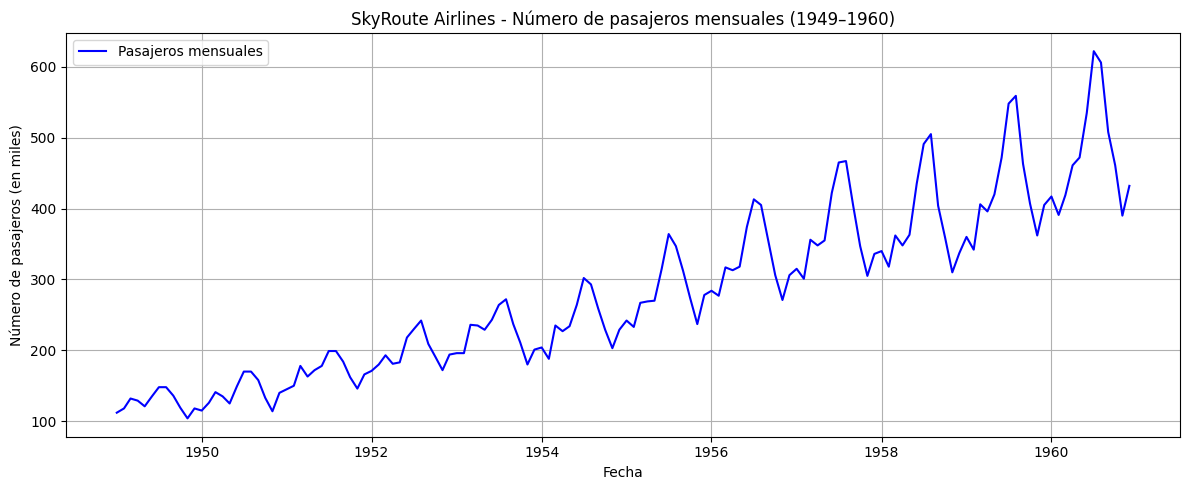

In [10]:
#Carga y visualización inicial

import pandas as pd
import matplotlib.pyplot as plt

# Cargar el dataset desde una URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df.rename(columns={"Passengers": "Passengers"}, inplace=True)

# Visualización de la serie temporal
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Passengers"], label="Pasajeros mensuales", color="blue")
plt.title("SkyRoute Airlines - Número de pasajeros mensuales (1949–1960)")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros (en miles)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- Tendencia creciente: El número de pasajeros aumenta de forma sostenida a lo largo de los años (1949–1960).
- Estacionalidad fuerte: Hay picos recurrentes que indican alta demanda en ciertos meses (posiblemente vacaciones o temporadas altas).
- Patrón repetitivo: La serie no parece ser puramente aleatoria; hay un patrón claro que puede modelarse.

## Descomposición de la serie

La descomposición estacional consiste en dividir una serie temporal en tres partes:

- Tendencia (trend): evolución general a largo plazo.
- Estacionalidad (seasonal): variaciones periódicas (por ejemplo, aumento de pasajeros en vacaciones).
- Residuo o ruido (resid): variaciones no explicadas ni por tendencia ni por estacionalidad (eventos atípicos o aleatorios).

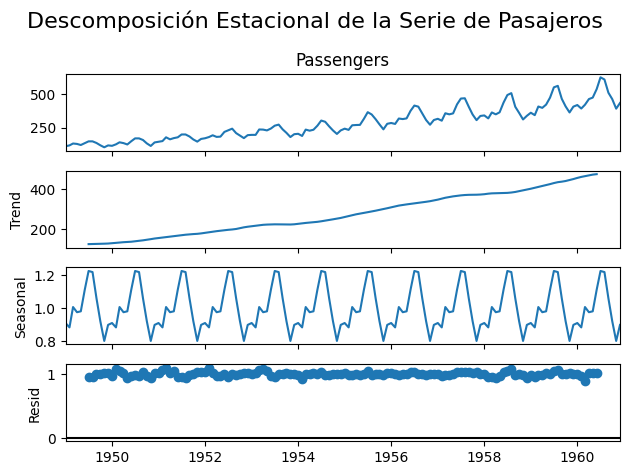

In [11]:
# Descomposición de la serie

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Usamos la serie ya cargada en un DataFrame llamado df con columna 'pasajeros'
# Asegurarnos que el índice sea de tipo datetime y tenga frecuencia mensual
df.index = pd.to_datetime(df.index)
df = df.asfreq('MS')  # MS: Month Start

# Aplicar descomposición estacional aditiva
result = seasonal_decompose(df['Passengers'], model='multiplicative')

# Graficar resultados
result.plot()
plt.suptitle("Descomposición Estacional de la Serie de Pasajeros", fontsize=16)
plt.tight_layout()
plt.show()


2. Tendencia (Trend).
- La tendencia es creciente de forma continua, lo que implica que la demanda del servicio aéreo aumentó de forma sostenida durante la década.
Esto puede estar relacionado con una mayor capacidad de la aerolínea, expansión de rutas, o crecimiento económico.

3. Estacionalidad (Seasonal).
- Hay un patrón anual claro: los mismos meses presentan los mismos comportamientos año con año.
Por ejemplo, cada año hay un aumento notorio en determinados meses (posiblemente julio-agosto y diciembre).

4. Residuo (Resid)
- El residuo o ruido es bastante bajo y aleatorio, lo que indica que la mayor parte de la variabilidad ya fue explicada por la tendencia y estacionalidad.
Esto es positivo: significa que podemos construir modelos precisos basados en estos componentes.

Esta descomposición justifica el uso de modelos como SARIMA, ya que:

- Hay estacionalidad clara → se requiere componente S en el modelo.
- Hay tendencia creciente → podría requerirse una diferenciación d=1.
- La serie es multiplicativa → es más apropiado usar modelos que consideren efectos proporcionales (como el modelo multiplicativo aplicado).

## Paso 1. Configuración inicial del modelo SARIMA.

In [12]:
# Modelo SARIMA: (p=1,d=1,q=1)x(P=1,D=1,Q=1,s=12)

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Modelo SARIMA: (p=1,d=1,q=1)x(P=1,D=1,Q=1,s=12)
sarima_model = SARIMAX(
    df['Passengers'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)
print(sarima_results.summary())


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -456.103
Date:                            Sun, 05 Oct 2025   AIC                            922.205
Time:                                    00:03:07   BIC                            936.016
Sample:                                01-01-1949   HQIC                           927.812
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2298      0.401     -0.573      0.567      -1.016       0.557
ma.L1         -0.0987      0.374   

Ya que el modelo está ajustado y los residuos son aceptables, podemos continuar con la predicción de los próximos 12 meses.

## pronóstico de los próximos 12 valores

In [13]:
# pronóstico de los próximos 12 valores

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

# Paso 1: Dividir los datos
n_periods = 12
train_data = df['Passengers'][:-n_periods]
test_data = df['Passengers'][-n_periods:]

# Paso 2: Ajustar el modelo SARIMA
model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

# Paso 3: Pronosticar los próximos 12 valores
forecast = results.get_forecast(steps=n_periods)
predicted_mean = forecast.predicted_mean

# Paso 4: Crear la tabla comparativa
comparison_df = pd.DataFrame({
    'Fecha': test_data.index,
    'Real': test_data.values,
    'Predicción SARIMA': predicted_mean.values,
    'Error Absoluto': abs(test_data.values - predicted_mean.values)
})

# Mostrar la tabla
print(comparison_df)


        Fecha  Real  Predicción SARIMA  Error Absoluto
0  1960-01-01   417         423.220775        6.220775
1  1960-02-01   391         406.433566       15.433566
2  1960-03-01   419         467.547433       48.547433
3  1960-04-01   461         457.478940        3.521060
4  1960-05-01   472         480.937601        8.937601
5  1960-06-01   535         534.599304        0.400696
6  1960-07-01   622         609.414970       12.585030
7  1960-08-01   606         621.009678       15.009678
8  1960-09-01   508         523.363515       15.363515
9  1960-10-01   461         468.643695        7.643695
10 1960-11-01   390         423.339480       33.339480
11 1960-12-01   432         465.073605       33.073605


Observaciones

- El modelo SARIMA realiza una estimación razonable para la mayoría de los meses.
- Los mayores errores se presentan en marzo, noviembre y diciembre, con errores absolutos cercanos o superiores a 30 unidades.
- El error absoluto más bajo se da en junio, con una diferencia de solo 0.4 pasajeros.

### Calculemos los errores:

In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Datos reales y predicciones
fechas = pd.date_range(start="1960-01-01", periods=12, freq='MS')
reales = [417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432]
predicciones = [423.220775, 406.433566, 467.547433, 457.478940, 480.937601,
                534.599304, 609.414970, 621.009678, 523.363515,
                468.643695, 423.339480, 465.073605]

# Cálculo de errores
mae = mean_absolute_error(reales, predicciones)
rmse = np.sqrt(mean_squared_error(reales, predicciones))  # Cambio aquí
mape = np.mean(np.abs((np.array(reales) - np.array(predicciones)) / np.array(reales))) * 100

# Imprimir resultados
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"MAPE (Error Porcentual Absoluto Medio): {mape:.2f}%")



MAE (Error Absoluto Medio): 16.67
RMSE (Raíz del Error Cuadrático Medio): 21.62
MAPE (Error Porcentual Absoluto Medio): 3.76%


## Visualización de las predicciones en conjunto con los datos reales:

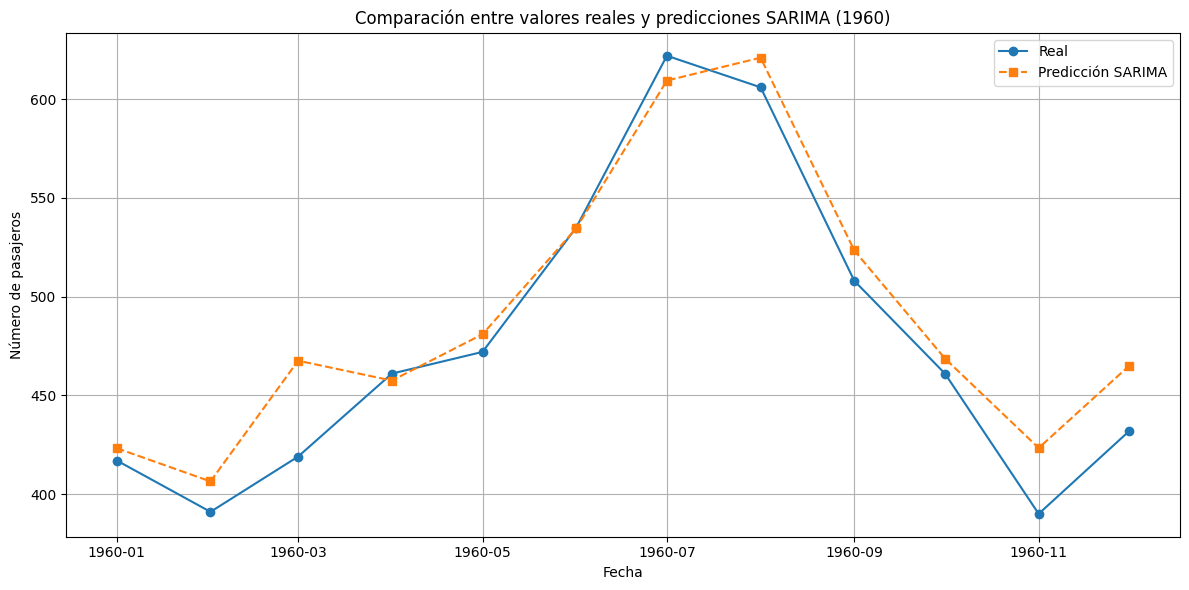

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear el DataFrame con datos reales y predicciones
fechas = pd.date_range(start="1960-01-01", periods=12, freq='MS')
reales = [417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432]
predicciones = [423.220775, 406.433566, 467.547433, 457.478940, 480.937601,
                534.599304, 609.414970, 621.009678, 523.363515,
                468.643695, 423.339480, 465.073605]

df_pred = pd.DataFrame({
    "Fecha": fechas,
    "Real": reales,
    "Predicción SARIMA": predicciones
})
df_pred.set_index("Fecha", inplace=True)

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(df_pred.index, df_pred["Real"], marker='o', label="Real")
plt.plot(df_pred.index, df_pred["Predicción SARIMA"], marker='s', linestyle='--', label="Predicción SARIMA")
plt.title("Comparación entre valores reales y predicciones SARIMA (1960)")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


El modelo SARIMA (1,1,1)x(1,1,1,12) se utilizó para predecir el número de pasajeros mensuales durante el año 1960. Los resultados muestran que el modelo logra capturar adecuadamente la tendencia creciente y el comportamiento estacional observado en la serie histórica de pasajeros.

**Evaluación del modelo:**

A partir de los datos reales y las predicciones, se calcularon las siguientes métricas de error:

- MAE (Error Absoluto Medio): 16.67
- RMSE (Raíz del Error Cuadrático Medio): 21.62
- MAPE (Error Porcentual Absoluto Medio): 3.76%

Estos valores reflejan que el modelo tiene un buen ajuste, con errores relativamente bajos y una alta capacidad predictiva para un modelo clásico sin uso de machine learning avanzado.

# Uso de regresiones para toma de decisiones estratégicas

## Exploración de Datos (EDA) inicial

In [16]:
# Exploración de Datos (EDA) inicial
# Importamos las librerías necesarias y cargamos el dataset:

import seaborn as sns
import pandas as pd

# Cargar el dataset
df = sns.load_dataset("mpg")
#Exploración inicial
print(df.head())

# Resumen general
print (df.info())

# Estadísticas descriptivas
print(df.describe())


    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2 

In [17]:
# Limpieza de datos

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# Eliminar filas con valores nulos
df_clean = df.dropna().copy()

# Confirmar que no haya valores nulos
print("\nDespués de limpiar:")
print(df_clean.isnull().sum())


Valores nulos por columna:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Después de limpiar:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


## Visualización de relaciones

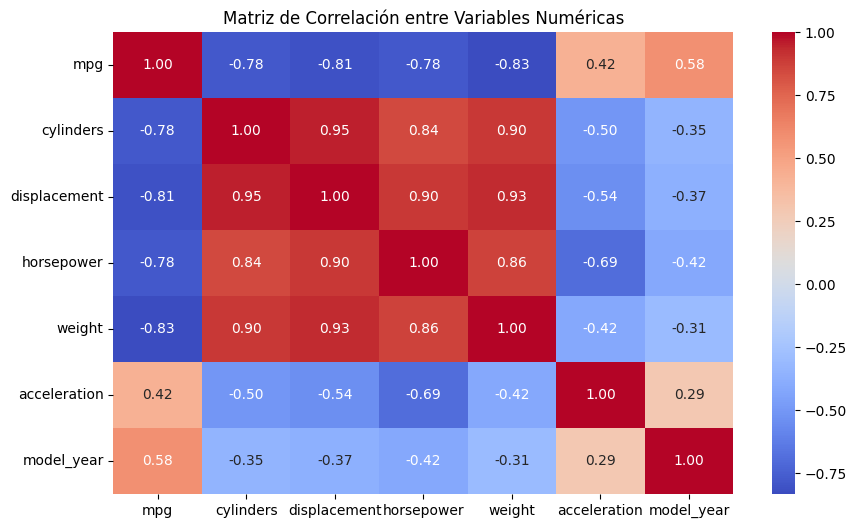

In [18]:
# a) Mapa de calor de correlación
# Calcular correlación
correlation = df_clean.corr(numeric_only=True)

# Visualizar correlaciones
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()


Resumen de hallazgos clave

- La variable objetivo mpg (millas por galón) muestra correlaciones fuertes negativas con:
  - weight (-0.83)
  - displacement (-0.81)
  - cylinders y horsepower (ambos en torno a -0.78)
- Tiene correlaciones positivas con:
  - model_year (0.58) – los autos más nuevos son más eficientes.
  - acceleration (0.42) – aunque no tan fuerte.
-Además, con los valores observados y de acuerdo con Kuhn & Johnson, (2020), se observa multicolinealidad entre:
  - weight, displacement, horsepower y cylinders (correlaciones > 0.84 entre ellas).
  - Esto es importante para evitar redundancia en la regresión múltiple.

### Análisis de una correlación lineal simple.

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     878.8
Date:                Sun, 05 Oct 2025   Prob (F-statistic):          6.02e-102
Time:                        00:13:51   Log-Likelihood:                -1130.0
No. Observations:                 392   AIC:                             2264.
Df Residuals:                     390   BIC:                             2272.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.2165      0.799     57.867      0.0

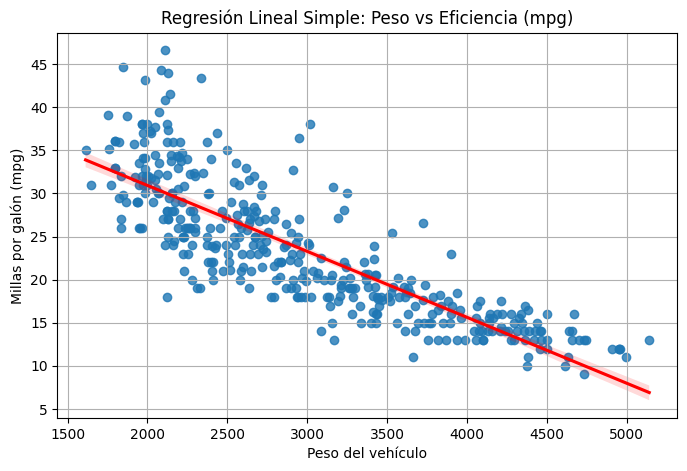

In [19]:
#Correlación simple
#Preparar los datos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Cargar dataset
df = sns.load_dataset('mpg').dropna()  # Eliminamos nulos por simplicidad

# Variable dependiente (Y) e independiente (X)
X = df['weight']
y = df['mpg']

# Agregar constante para el modelo
X = sm.add_constant(X)

#Ajustar el modelo
modelo_simple = sm.OLS(y, X).fit()
print(modelo_simple.summary())

# Gráfico
plt.figure(figsize=(8, 5))
sns.regplot(x='weight', y='mpg', data=df, line_kws={"color": "red"})
plt.title('Regresión Lineal Simple: Peso vs Eficiencia (mpg)')
plt.xlabel('Peso del vehículo')
plt.ylabel('Millas por galón (mpg)')
plt.grid(True)
plt.show()


Interpretación del gráfico

- Los puntos azules representan observaciones reales.
- La línea roja es la recta de regresión ajustada.
- Se observa que, a mayor peso, menor mpg, lo cual confirma el coeficiente negativo del modelo (-0.0076).
- La dispersión indica que, si bien el modelo es útil, no es perfecto: hay variabilidad que no se explica solo por el peso.


Objetivo del modelo

Predecir mpg a partir de:

- weight
- horsepower
- acceleration
- model_year

In [21]:
# Regresión múltiple

import statsmodels.api as sm

# Eliminar filas con valores nulos
df_clean = df.dropna(subset=['horsepower', 'weight', 'acceleration', 'model_year'])

# Variables independientes
X = df_clean[['weight', 'horsepower', 'acceleration', 'model_year']]
X = sm.add_constant(X)  # Agregar término constante

# Variable dependiente
y = df_clean['mpg']

# Modelo OLS
model = sm.OLS(y, X).fit()

# Resumen del modelo
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     408.8
Date:                Sun, 05 Oct 2025   Prob (F-statistic):          1.72e-137
Time:                        00:16:37   Log-Likelihood:                -1037.1
No. Observations:                 392   AIC:                             2084.
Df Residuals:                     387   BIC:                             2104.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -15.3889      4.671     -3.294   

Esto indica que el modelo explica el 81% de la varianza en la eficiencia del vehículo (mpg), lo cual es muy bueno para un modelo lineal simple, considerando que no usamos todas las variables posibles.

### Visualización del rendimiento del modelo de regresión múltiple comparando valores reales vs predichos.

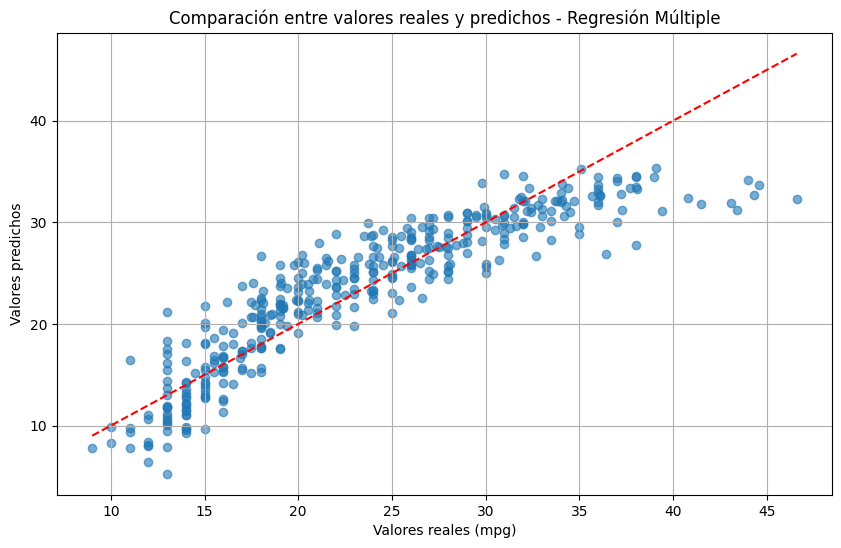

In [22]:
# visualización del modelo

import matplotlib.pyplot as plt
import statsmodels.api as sm

# Ajuste del modelo
model = sm.OLS(y, X).fit()
predictions = model.predict(X)

# Gráfico de comparación
plt.figure(figsize=(10, 6))
plt.scatter(y, predictions, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.xlabel("Valores reales (mpg)")
plt.ylabel("Valores predichos")
plt.title("Comparación entre valores reales y predichos - Regresión Múltiple")
plt.grid(True)
plt.show()


**1. Resumen del modelo**

- Tipo: Regresión lineal múltiple
- Variables predictoras: weight, horsepower, acceleration, model_year
- Desempeño del modelo:
  - R² = 0.809 → Explica el 81% de la variabilidad en el rendimiento de combustible.
  - Variables significativas: weight (negativo) y model_year (positivo)
  - Visualmente, los valores predichos se alinean razonablemente con los reales (ver gráfica), aunque hay ligera dispersión en los extremos.

# Integración de procesos ETL y análisis estadístico

En el ecosistema actual de ciencia de datos, la integración efectiva entre los procesos ETL (Extracción, Transformación y Carga) y el análisis estadístico representa un pilar fundamental para garantizar la validez de los insights generados. Según un estudio reciente de Gartner (2023), el 68% de los proyectos analíticos fallidos atribuyen su deficiencia a problemas en las etapas tempranas de preparación y transformación de datos.



## El ciclo ETL-estadístico

- Extracción: Obtención de datos crudos de diversas fuentes
- Transformación estadística:
  - Limpieza basada en propiedades estadísticas
  - Ingeniería de características con validación estadística
  - Normalización/estandarización
- Carga: Almacenamiento optimizado para análisis
- Retroalimentación: Uso de resultados estadísticos para refinar ETL

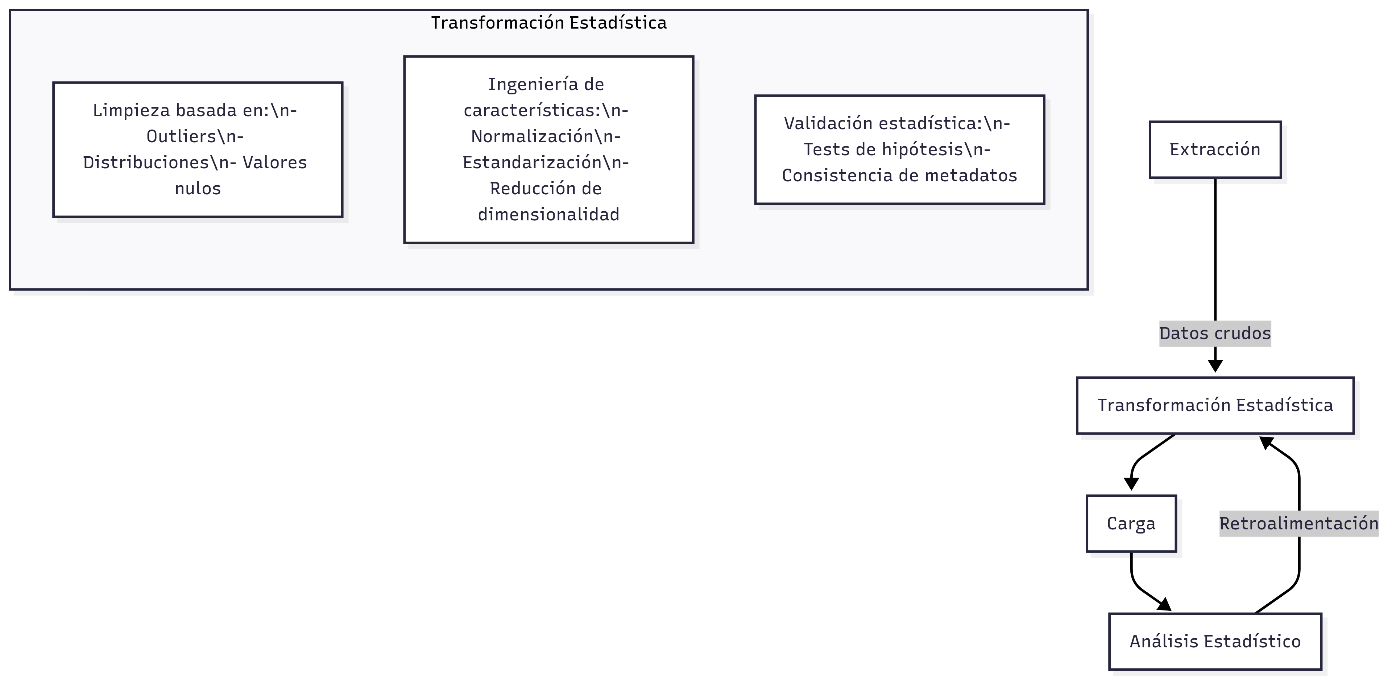

## Requisitos estadísticos para ETL de calidad

- Consistencia
- Completitud
- Exactitud
- Actualidad
- Trazabilidad

**Relación con el Análisis**

Estas dimensiones son críticas para garantizar que los resultados analíticos sean:

- Confiables (Consistencia, Exactitud),
- Representativos (Completitud),
- Oportunos (Actualidad), y
- Auditables (Trazabilidad).

# Transformaciones ETL con fundamento estadístico.

## Técnicas avanzadas implementables en ETL:

In [23]:
# Extracción del dataset
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

df['MedHouseVal'] = data.target  # Variable objetivo

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


## Ingeniería de características estadísticas

In [24]:
# Transformación: Creación de variables nuevas y filtrado
df['Income_per_Pop'] = df['MedInc'] / df['Population']
df = df[df['MedHouseVal'] < 5]  # Eliminamos outliers (el tope artificial era 5.0)


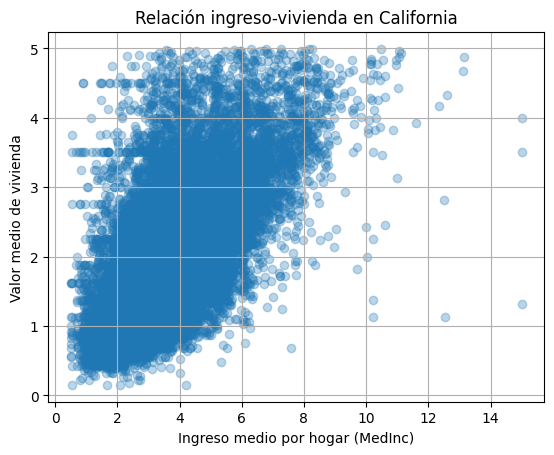

In [25]:
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.3)
plt.xlabel('Ingreso medio por hogar (MedInc)')
plt.ylabel('Valor medio de vivienda')
plt.title('Relación ingreso-vivienda en California')
plt.grid(True)
plt.show()


In [26]:
# Correlaciones principales
correlaciones = df.corr(numeric_only=True)['MedHouseVal'].sort_values(ascending=False)
print(correlaciones)


MedHouseVal       1.000000
MedInc            0.646719
AveRooms          0.111581
Income_per_Pop    0.085815
HouseAge          0.065139
Population        0.013592
AveOccup         -0.021205
Longitude        -0.045733
AveBedrms        -0.061480
Latitude         -0.149257
Name: MedHouseVal, dtype: float64


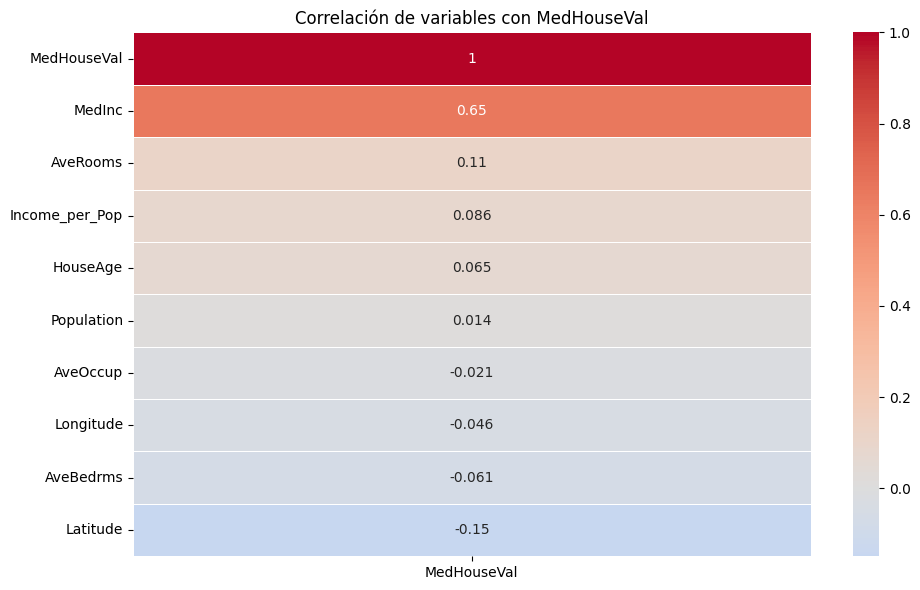

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calcular matriz de correlación (solo variables numéricas)
corr_matrix = df.corr(numeric_only=True)

# Crear heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix[['MedHouseVal']].sort_values(by='MedHouseVal', ascending=False),
            annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlación de variables con MedHouseVal')
plt.tight_layout()
plt.show()


# Consideraciones éticas en la gestión y análisis de datos

En la era de la transformación digital, donde los datos se han convertido en el activo más valioso para las organizaciones, las consideraciones éticas en su gestión y análisis han emergido como un pilar fundamental. Según un informe del Foro Económico Mundial (2023), el 78% de los líderes empresariales reconocen que los desafíos éticos en el manejo de datos representan uno de los principales obstáculos para la implementación exitosa de proyectos de analítica e inteligencia artificial.



Un estudio de Zuboff (2023) destaca cómo la creciente capacidad de procesamiento ha hecho necesario desarrollar marcos éticos más sofisticados que los simples consentimientos informados.



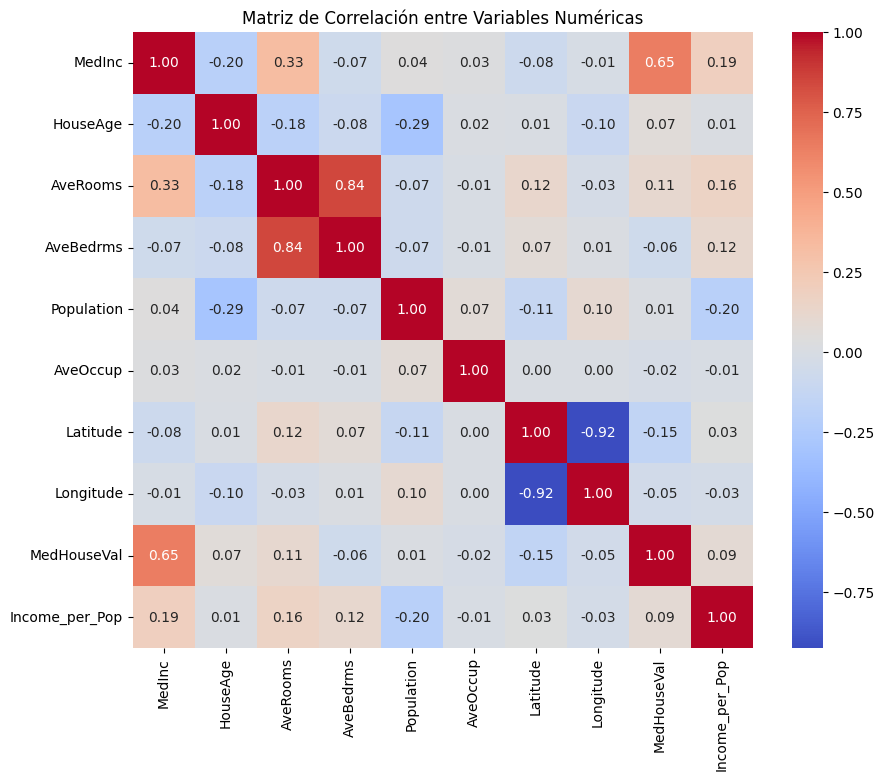

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de correlación
correlation_matrix = df.corr(numeric_only=True)

# Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()


## Técnicas avanzadas de anonimización

In [41]:
!pip install anonympy

import pandas as pd
from anonympy.pandas import dfAnonymizer
from anonympy.pandas.utils_pandas import load_dataset

In [42]:
df44 = load_dataset()
print(df44)

    name  age  birthdate    salary                                   web  \
0  Bruce   33 1915-04-17  59234.32  http://www.alandrosenburgcpapc.co.uk   
1   Tony   48 1970-05-29  49324.53     http://www.capgeminiamerica.co.uk   

                  email        ssn  
0  josefrazier@owen.com  343554334  
1       eryan@lewis.com  656564664  


In [44]:
import pandas as pd
from anonympy.pandas import dfAnonymizer

data = pd.read_csv('health_records.csv')

anon=dfAnonymizer(data)
#anon.ann

FileNotFoundError: [Errno 2] No such file or directory: 'health_records.csv'